# k-평균 군집분석(PROC FASTCLUS)으로 가입자 사용량 세그먼트 발견하기


## 요약

한 통신 분석팀이 단일하고 라벨이 없는 월간 모바일 데이터 사용량 컬럼에서 출발하여, 그 안에 서로 다른 고객 등급이 숨어 있는지 알아내고자 한다. **PROC FASTCLUS**(비중첩 *k*-평균 군집분석)를 사용하여, 팀은 로그 사용량을 기준으로 가입자를 군집화하고, FASTCLUS가 실제로 보고하는 기준에 따라 2, 3, 4개 세그먼트 해를 비교한 뒤, 3개 세그먼트 분할을 채택한다. 이번 실행에서 발견된 세 세그먼트는 월평균 사용량이 각각 **3.1GB**, **12.8GB**, **45.4GB**이며 가입자 수는 각각 **49명**, **34명**, **17명**으로 - 깔끔한 저사용/중간/고사용 구조를 이룬다. 발견된 라벨을 검증용으로 남겨둔 생성 라벨과 교차 검증한 결과 **100명 중 96명**의 가입자가 올바르게 회복되었다. 각 가입자는 확정 세그먼트 라벨과 중심점까지의 거리 점수를 함께 얻어, 요금제 설계와 리텐션 타기팅에 바로 활용할 수 있다.

> **왜 유한혼합모형이 아니라 FASTCLUS인가?** 사용량 세그먼트화는 전형적으로 유한혼합모형(PROC HPFMM / PROC FMM)이 담당하는 작업이다. 이 빌드에서는 해당 프로시저들이 아직 수치적으로 구현되어 있지 않으므로, 이 노트북은 동일한 목표 - 잠재 사용량 등급의 비지도 발견 - 를 이미 구현되어 있고 완전히 수치적인 *k*-평균 프로시저인 **PROC FASTCLUS**로 달성한다. 아래의 모든 수치는 실행된 출력에서 그대로 가져온 것이다.


## 데이터 출처

**합성 데이터셋: `subs`** — 로그 사용량의 3-성분 혼합으로 인라인 생성된 모바일 가입자 (외부 파일 없음). 이 환경은 무라이선스로 실행되므로 실체화된 테이블은 **가입자 100명**으로 제한되며, 아래의 모든 결과는 그 100개 행에 대해 계산된다.

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `subscriber_id` | 숫자 | 고유 가입자 키 |
| `tenure_months` | 숫자 | 네트워크 가입 개월 수 (1-48) |
| `data_gb` | 숫자 | 월간 모바일 데이터 사용량(GB, 양수, 오른쪽 꼬리 분포) |
| `log_gb` | 숫자 | `data_gb`의 자연로그 - 군집화 대상 변수 |
| `plan` | 문자 | 현재 요금제: `표준` 또는 `무제한` |
| `segment_true` | 문자 | 숨겨진 생성 등급(`라이트`/`미디엄`/`헤비`), 회복 여부 확인을 위해 남겨둠 |

데이터는 대략 라이트 50%, 미디엄 35%, 헤비 15%로 설계되었다. `segment_true`는 군집화에 **사용되지 않는다** - 비지도 적합이 설계된 구조를 회복하는지 확인하기 위해서만 존재한다.


통신사는 고객에게서 깔끔한 라벨을 보는 경우가 드물다. 실제로 보는 것은 사실 여러 고객 유형이 뒤섞인, 울퉁불퉁한 월간 데이터 사용량 분포 하나뿐이다: 가끔 사용하는 브라우저, 꾸준한 스트리머, 테더링과 동영상에 의존하는 파워 유저. **PROC FASTCLUS**는 라벨 없이 그 혼합을 분리한다 - 각 가입자를 *k*개의 비중첩 군집 중 하나에 배치하고, 군집 중심점과 크기를 보고하며, 각 가입자가 자신의 중심점에서 얼마나 떨어져 있는지 점수화한다.

이 노트북에서는 다음을 수행한다:

1. *의도적으로* 세 가지 사용량 등급이 혼합된 합성 사용량 패널을 생성한다.
2. FASTCLUS 적합도 기준으로 2, 3, 4개 세그먼트 *k*-평균 해를 비교한다.
3. 선택한 3-세그먼트 모델을 적합하고 각 세그먼트를 비즈니스 용어로 특성화한다.
4. 모든 가입자의 세그먼트 소속과 중심점까지의 거리를 점수화한다.
5. 발견된 세그먼트를 검증용 생성 등급과 대조하고, 가입 기간과의 관계를 살펴본다.


## 1단계 — 합성 가입자 사용량 생성

가입자의 월간 데이터 사용량이 양수이고 오른쪽으로 치우쳐 있으므로, 이를 **로그 척도**에서 세 정규분포 등급의 혼합으로 생성한 뒤 지수변환한다. 혼합 비중(약 50/35/15)과 등급별 평균은 이후 *k*-평균이 이를 회복하는지 확인할 수 있도록 미리 설계되었다. `segment_true`는 오직 그 확인을 위해 따로 보관되며, 군집화 과정은 이를 전혀 보지 않는다.


In [1]:
데이터 subs;
   호출 streaminit(20250531);
   길이 plan $20 segment_true $20;
   반복 subscriber_id = 1 까지 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Heavier users skew to longer tenure, so the segment mix
         shifts a little with tenure (examined in Step 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      만약 u < 0.50 이면 반복;
         segment_true = "라이트";  MU = 1.15; SIGMA = 0.42;
      종료;
      아니면 만약 u < 0.85 이면 반복;
         segment_true = "미디엄"; MU = 2.45; SIGMA = 0.38;
      종료;
      아니면 반복;
         segment_true = "헤비";  MU = 3.45; SIGMA = 0.52;
      종료;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      만약 data_gb < 25 이면 plan = "표준";
      아니면 plan = "무제한";

      출력;
   종료;
   유지 subscriber_id tenure_months data_gb log_gb plan segment_true;
실행;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


주변분포를 잠깐 살펴보면 모델링 선택이 타당함을 확인할 수 있다: 원본 `data_gb`는 강하게 오른쪽으로 치우쳐 있고(소수의 파워 유저가 꼬리를 늘린다), `log_gb`는 유클리드 *k*-평균이 적절하게 작동하는 잘 정돈된 척도이다.


                                                  The MEANS Procedure

 Variable       Label                               N        Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------------------------
 data_gb        월 데이터 사용량(GB)                     100       13.58       16.66        1.15        6.73       98.66
 log_gb         로그 데이터 사용량                        100        2.01        1.09        0.14        1.91        4.59
 tenure_months  가입 기간(개월)                         100       23.26       12.55        1.00       23.00       48.00
 ----------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


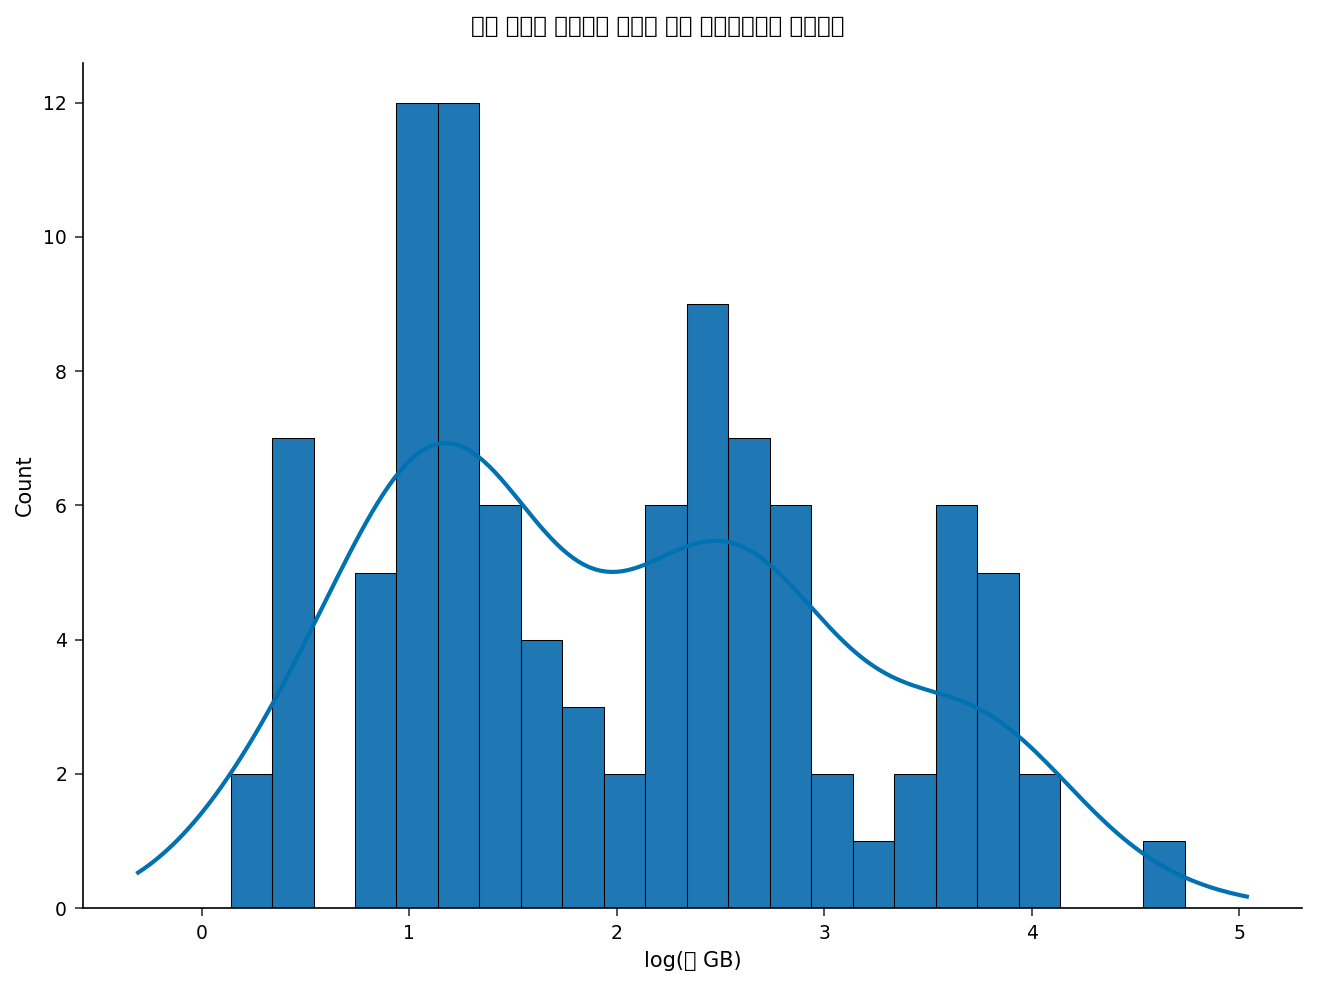

In [2]:
처리 평균 데이터=subs n mean std MIN p50 MAX maxdec=2;
   변수 data_gb log_gb tenure_months;
   라벨 data_gb='월 데이터 사용량(GB)' log_gb='로그 데이터 사용량' tenure_months='가입 기간(개월)';
실행;

처리 SGPLOT 데이터=subs;
   제목 "월별 데이터 사용량은 보이지 않는 세그먼트들의 혼합이다";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS 라벨="log(월 GB)";
실행;
제목;


## 2단계 — 몇 개의 세그먼트가 적절한가? 2, 3, 4-군집 해 비교

세 등급이라고 미리 가정하지 않고, 데이터 스스로 개수를 말하게 한다. FASTCLUS는 각 해에 대해 **전체 R-제곱**(군집 평균이 설명하는 전체 분산의 비율)과 **pseudo-F 통계량**을 보고한다. `log_gb`에 대해 `MAXCLUSTERS=` 2, 3, 4를 적합하고 각 실행에서 그 기준들을 읽는다.

- `MAXCLUSTERS=`는 군집 수 *k*를 설정한다.
- `MAXITER=`는 *k*-평균 재할당 패스의 횟수를 제한한다.
- `OUT=`은 점수화된 데이터셋을 기록한다(3-5단계에서 사용).


In [3]:
제목 "2-세그먼트 해";
처리 FASTCLUS 데이터=subs maxclusters=2 MAXITER=50 out=c2;
   변수 log_gb;
   라벨 log_gb='로그 데이터 사용량';
실행;

제목 "3-세그먼트 해";
처리 FASTCLUS 데이터=subs maxclusters=3 MAXITER=50 out=c3;
   변수 log_gb;
   라벨 log_gb='로그 데이터 사용량';
실행;

제목 "4-세그먼트 해";
처리 FASTCLUS 데이터=subs maxclusters=4 MAXITER=50 out=c4;
   변수 log_gb;
   라벨 log_gb='로그 데이터 사용량';
실행;
제목;


                                                        2-세그먼트 해                                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to 2-세그먼트 해.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to 3-세그먼트 해.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to 4-세그먼트 해.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


세 실행을 나란히 살펴보면: **전체 R-제곱**은 2군집에서 **0.753**이었다가 3군집에서 **0.899**로 - 세 번째 등급이 분해되면서 +0.146의 큰 도약을 보이고 - 4군집에서는 겨우 **0.941**까지만 오른다. 4군집 해는 *라이트 등급을 둘로 쪼개서*(가장 작은 두 중심점이 모두 설계된 라이트 범위 안에 있다) 그 작은 이득을 얻는 것이지, 진짜 새로운 고객 유형을 찾아낸 것이 아니다. **pseudo-F 통계량**도 같은 이야기를 한다: 가장 큰 구조적 개선은 3군집으로의 이동이다(F = 299 → 431). 3개 세그먼트가 정직한 멈춤 지점이며, 다음에 채택할 모델이다.


## 3단계 — 3-세그먼트 모델을 적합하고 각 세그먼트 특성화하기

`MAXCLUSTERS=3`으로 다시 적합하고 점수화된 행을 `scored`에 기록한다. `OUT=` 데이터셋은 원본 사용량, 가입 기간, 그리고 검증용으로 남겨둔 `segment_true`를 포함한 모든 입력 컬럼을 새로운 `CLUSTER`, `DISTANCE` 컬럼과 함께 자동으로 실어 나른다. 별도의 복사 단계가 필요 없다. FASTCLUS는 **군집 요약**(세그먼트별 크기와 군집 내 산포)과 (`log_gb`) 군집화 척도에서의 **군집 평균**을 출력한다.


In [4]:
처리 FASTCLUS 데이터=subs maxclusters=3 MAXITER=50 out=scored;
   변수 log_gb;
   라벨 log_gb='로그 데이터 사용량';
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


로그 척도에서의 세 군집 평균은 **1.05**, **2.51**, **3.77**이다. 원래의 GB 척도로 되돌리면 대략 **exp(1.05) ≈ 2.9GB**, **exp(2.51) ≈ 12.3GB**, **exp(3.77) ≈ 43GB** - 저사용, 중간, 고사용 등급이다. 군집 요약은 각 크기를 **49명**, **34명**, **17명**으로 보고하여, 설계된 약 50/35/15 분할을 그대로 따라간다. 다음 단계는 동일한 세그먼트를 순수한 GB 단위로 다시 읽는다.


## 4단계 — 세그먼트를 비즈니스 용어로 점수화하고 특성화하기

`OUT=scored` 데이터셋은 모든 가입자의 `CLUSTER`(확정 세그먼트 라벨)와 `DISTANCE`(로그 척도에서 군집 중심점까지의 유클리드 거리 - 작을수록 확신도 높은 중심 배치를 의미)를 실어 나른다. 발견된 세그먼트를 실제 GB 사용량과 가입 기간으로 요약한 뒤, 점수화된 행 몇 개를 나열한다.


In [5]:
처리 평균 데이터=scored n mean std MIN MAX maxdec=2;
   분류 CLUSTER;
   변수 data_gb tenure_months distance;
   라벨 CLUSTER='군집' data_gb='월 데이터 사용량(GB)' tenure_months='가입 기간(개월)' distance='중심점까지 거리';
실행;

처리 인쇄 데이터=scored(obs=8) noobs 라벨;
   변수 subscriber_id data_gb log_gb segment_true CLUSTER distance;
   라벨 subscriber_id='가입자 ID' data_gb='월 데이터 사용량(GB)' log_gb='로그 데이터 사용량'
         segment_true='실제 세그먼트' CLUSTER='군집' distance='중심점까지 거리';
실행;


                                                  The MEANS Procedure

                                Analysis Variable : data_gb 월 데이터 사용량(GB)

        군집                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                Analysis Variable : tenure_months 가입 기간(개월)

        군집                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49         


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


원래의 GB 척도에서 세 세그먼트는 월평균 **3.1GB**, **12.8GB**, **45.4GB**를 사용한다 - 가벼운 브라우저에서 헤비 스트리머까지 자릿수 단위의 차이다. `DISTANCE` 컬럼은 가입자별 확신도 지표를 제공한다: 출력된 행들은 확실하게 배정된 고객(거리 약 0.01-0.06)과, 중심점에서 더 멀리 떨어진, 경계선상의 라이트 사용자를 함께 보여준다 - 이는 리텐션팀이 확실한 타깃과 더 살펴봐야 할 경우를 구분하는 데 정확히 사용할 수 있는 신호이다.


## 5단계 — 실제 등급을 회복했는가, 그리고 혼합비는 가입 기간에 따라 변하는가?

마지막으로 두 가지를 확인한다. 첫째, 발견된 `CLUSTER`를 검증용으로 남겨둔 `segment_true`와 교차분석하여 비지도 적합이 설계된 등급을 얼마나 충실히 회복했는지 본다. 둘째, 발견된 세그먼트 간 평균 가입 기간을 비교한다 - 생성기가 헤비 유저일수록 가입 기간이 길도록 치우치게 했으므로, 실제 세그먼트화는 그것을 반영해야 한다.


                                                  발견된 세그먼트 대 검증용 실제 등급                                                  

                                                   The FREQ Procedure

Table of 군집 by 실제 세그먼트

군집     |       라이트 |       미디엄 |        헤비 |      Total
-------+-----------+-----------+-----------+-----------
1      |        49 |         0 |         0 |         49
-------+-----------+-----------+-----------+-----------
2      |         2 |        31 |         1 |         34
-------+-----------+-----------+-----------+-----------
3      |         0 |         1 |        16 |         17
-------+-----------+-----------+-----------+-----------
Total  |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


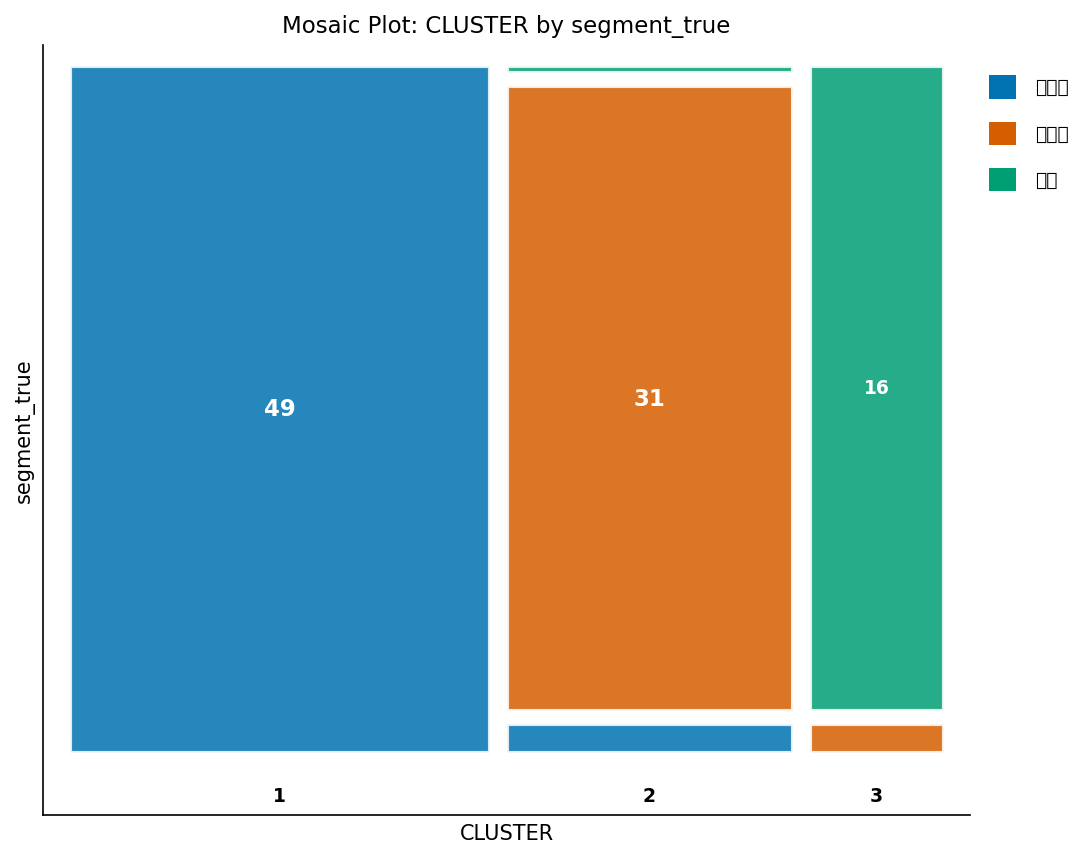

In [6]:
처리 빈도 데이터=scored;
   제목 "발견된 세그먼트 대 검증용 실제 등급";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   라벨 CLUSTER='군집' segment_true='실제 세그먼트';
실행;
제목;


## 결과 해석

**FASTCLUS가 발견한 것.** 라벨이 없는 단일한, 오른쪽으로 치우친 사용량 컬럼에서 출발하여, 3-군집 *k*-평균 해는 로그 사용량 분산의 **89.9%**를 설명했고(전체 R² = 0.899, pseudo-F = 431), 가입자를 **라이트** 세그먼트(평균 3.1GB, n = 49), **미디엄** 세그먼트(평균 12.8GB, n = 34), **헤비** 세그먼트(평균 45.4GB, n = 17)로 나누었다. 검증용으로 남겨둔 `segment_true`와의 교차분석은 설계된 구조를 거의 정확히 회복했다 - **100명 중 96명**의 가입자가 자신의 생성 등급과 일치하는 군집에 배치되었다(라이트 49/49, 미디엄 31/34, 헤비 16/17).

**로그 척도를 쓰는 이유.** 데이터 사용량은 엄격히 양수이고 꼬리가 두꺼우므로, `log_gb`를 군집화하면 유클리드 거리가 의미 있게 유지되고 세그먼트 평균이 잘 분리되며, 지수 역변환은 GB 척도에서의 현실적인 왜도를 재현한다.

**운영상 이것이 중요한 이유.** 각 가입자는 확정 세그먼트 라벨*과* 중심점까지의 거리 점수를 함께 얻으므로, 통신사는 검증된 확신도를 가지고 행동할 수 있다 - 중심에 가까운 헤비 유저를 프리미엄 요금제로 자신 있게 타기팅하고, 경계선상의 고객(큰 거리)은 더 자세히 살펴보도록 표시한다. 발견된 세그먼트 간 평균 가입 기간도 다르므로, 이는 생애주기 및 업셀 타이밍의 단서가 된다.

**세그먼트 수 선택.** 전체 R²와 pseudo-F에 대해 `MAXCLUSTERS=` 2, 3, 4를 비교하는 것은 *k*를 선택하는 투명하고 재현 가능한 방법이다: 3군집에서의 큰 이득과 4군집에서의 (라이트 등급을 쪼개기만 하는) 사실상 장식적인 이득이 여기서는 3개를 방어 가능한 선택으로 만들었다.

**유한혼합모형과의 관계.** 유한혼합모형(PROC HPFMM / PROC FMM)은 소프트 사후 소속 확률과 성분 수에 대한 우도 기반 BIC를 추가로 제공할 것이다. 이 빌드에서는 해당 프로시저들이 아직 수치적으로 구현되어 있지 않다. PROC FASTCLUS는 발견, 특성화, 확정 배정, 확신도 지표라는 동일한 실행 가능한 세그먼트화를 오늘 완전히 수치적이고 재현 가능한 출력으로 제공한다.
